# Classificação de Grãos (Dry Bean Dataset) com aprendizado profundo

**Objetivo:** classificar 7 tipos de feijão seco (Seker, Barbunya, Bombay, Cali, Dermason, Horoz e Sira) a partir de atributos morfológicos, usando um MLP em PyTorch.

**Desafios:** classes desbalanceadas e atributos em escalas muito diferentes.

**Decisões tomadas**: divisão estratificada treino/validação/teste, padronização ajustada só no treino, pesos de classe na loss, BatchNorm + Dropout + weight decay, AdamW com `ReduceLROnPlateau`, gradient clipping, early stopping com checkpoint do melhor modelo e avaliação por F1 macro e acurácia balanceada.

In [3]:
import copy
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [4]:
def find_file(name):
    for p in (os.path.join('data', name), name):
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'{name} não encontrado em data/ nem na pasta atual')

df = pd.read_csv(find_file('beans_train.csv'))
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA


Como queremos treinar um modelo que seja capaz de classificar de forma correta as classes de grãos, vamos retirar a coluna de classe dos grãos do dataset de treino e utilizá-la como saída esperada. Devemos também transformar a coluna "Class" de string para numérico, já que trabalharemos com redes neurais.

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

encoder = LabelEncoder()
y = encoder.fit_transform(y)

Agora que as saídas já estão codificadas, podemos realizar a divisão do conjunto de dados. Porém, essa divisão deve ser feita de forma estratificada, pois já foi avisado que o dataset contém classes desbalanceadas. Além disso, usaremos o StandardScaler para normalizar a escala dos atributos, ajustado apenas no treino.

In [6]:
X_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)    
x_test = scaler.transform(x_test)

Esses gráficos servem para visualizar o desbalanceamento do dataset e a diferença de tamanho entre as classes. Como as classes são desbalanceadas, a acurácia global sozinha seria enganosa: usaremos também **F1 macro** e **acurácia balanceada**, que dão o mesmo peso a cada classe.

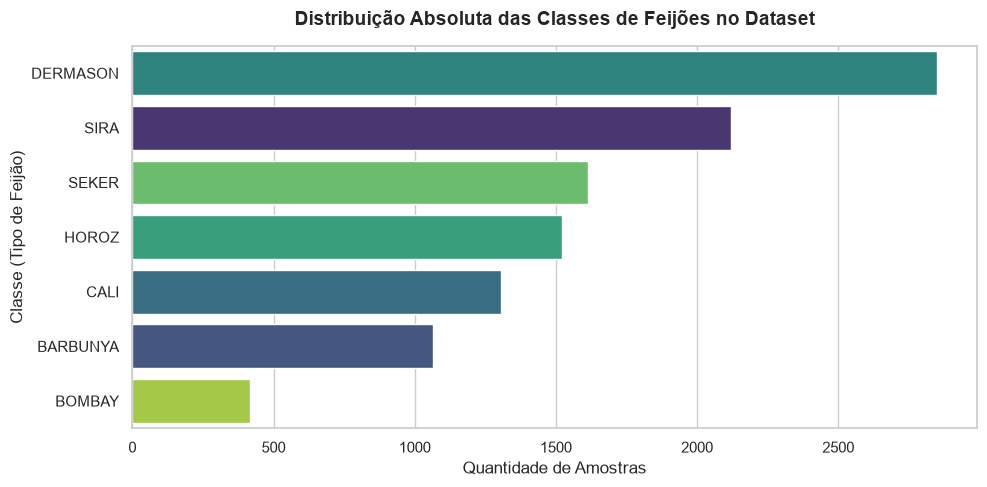

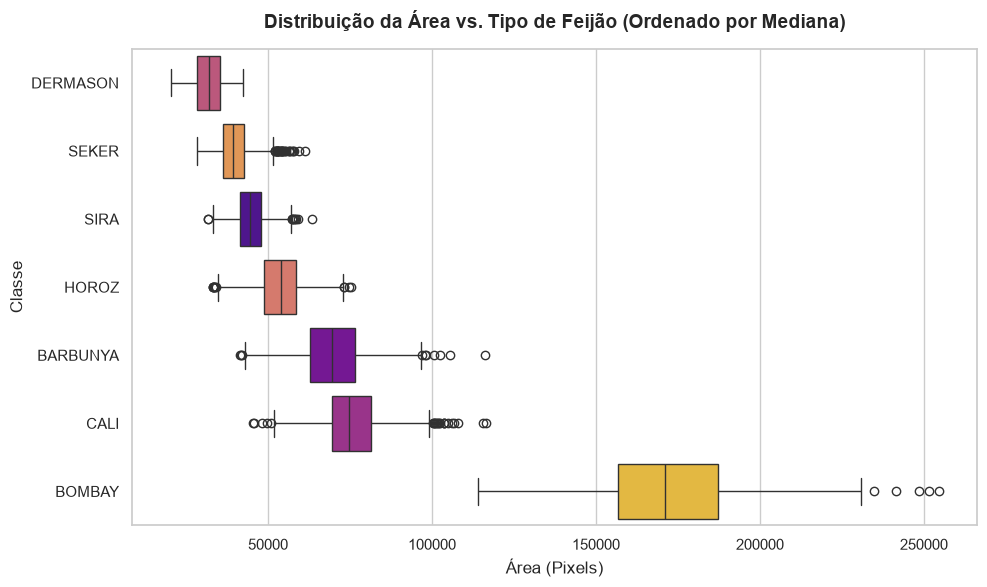

In [7]:


sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

plt.figure(figsize=(10, 5))
order_class = df['Class'].value_counts().index
sns.countplot(data=df, y='Class', order=order_class, hue='Class', palette='viridis', legend=False)

plt.title('Distribuição Absoluta das Classes de Feijões no Dataset', fontweight='bold', pad=15)
plt.xlabel('Quantidade de Amostras')
plt.ylabel('Classe (Tipo de Feijão)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
order_boxplot = df.groupby('Class')['Area'].median().sort_values().index
sns.boxplot(data=df, x='Area', y='Class', order=order_boxplot, hue='Class', palette='plasma', legend=False)

plt.title('Distribuição da Área vs. Tipo de Feijão (Ordenado por Mediana)', fontweight='bold', pad=15)
plt.xlabel('Área (Pixels)')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

In [8]:


X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Para garantir a **estabilidade** e a reprodutibilidade do processo de treinamento, fixamos as sementes aleatórias do PyTorch e do NumPy. Sem isso, a inicialização dos pesos da rede e o embaralhamento (`shuffle=True`) do `train_loader` variam a cada execução, o que dificultaria comparar resultados e justificar as decisões de regularização tomadas mais adiante.

In [9]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


**Arquitetura.** Os dados são tabulares, então um MLP é adequado: não há estrutura espacial ou sequencial que justifique CNN/RNN. A **BatchNorm** estabiliza a distribuição das ativações e favorece gradientes bem comportados; o **Dropout** (0.3) regulariza reduzindo a co-adaptação entre neurônios.

In [10]:
class MLPBeanClassifier(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.3):
        super(MLPBeanClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

input_dim = x_train.shape[1] 
num_classes = len(encoder.classes_)   # em vez de 7 fixo

model = MLPBeanClassifier(input_dim, num_classes)

**Desbalanceamento, otimização e regularização.**

- **Pesos de classe:** calculamos os pesos com `compute_class_weight('balanced')` (somente com o treino) e os acoplamos à `CrossEntropyLoss`. Assim o modelo é penalizado mais fortemente ao errar as classes minoritárias, evitando viés em direção às classes maiores.
- **AdamW com `weight_decay`:** otimizador adaptativo com penalização L2 desacoplada, que limita o tamanho dos pesos e ajuda a generalizar (regularização).
- **`ReduceLROnPlateau`:** reduz o learning rate pela metade quando a loss de validação não melhora por 5 épocas. O objetivo é refinar a convergência no final do treino, com passos menores quando a validação estagna (estabilidade).

In [11]:
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

pesos_tensor = torch.tensor(pesos, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=pesos_tensor)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

**Loop de treinamento com controles de estabilidade.**

- **Gradient clipping** (norma máxima 1.0): evita passos muito grandes causados por batches atípicos.
- **Scheduler:** `scheduler.step(val_loss)` a cada época.
- **Early stopping:** interrompe se a loss de validação não melhorar por `patience` épocas, evitando treinar além do ponto de melhor generalização (também é uma forma de regularização).
- **Checkpoint:** guarda os pesos da época com menor loss de validação e os restaura ao final.

In [12]:
epochs = 200      
patience = 15     
wait = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
lrs = []


best_val_loss = float('inf')
best_model_state = None
best_epoch = -1

for epoch in range(epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # estabilidade: limita a norma do gradiente
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_losses.append(running_loss / len(train_loader.dataset))
    train_accs.append(100 * correct_train / total_train)
    
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_losses.append(val_loss / len(val_loader.dataset))
    val_accs.append(100 * correct_val / total_val)

    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val_loss - 1e-4:
        best_val_loss = val_losses[-1]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
    
    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1:03d}/{epochs} | '
              f'Loss Treino: {train_losses[-1]:.4f} | Acc Treino: {train_accs[-1]:.2f}% | '
              f'Loss Val: {val_losses[-1]:.4f} | Acc Val: {val_accs[-1]:.2f}% | lr: {lrs[-1]:.1e}')
    
    if wait >= patience:
        print(f'\nEarly stopping na época {epoch+1} (sem melhora há {patience} épocas).')
        break
    
model.load_state_dict(best_model_state)
print(f'Melhor modelo obtido na época {best_epoch} (Loss Val = {best_val_loss:.4f}). Pesos restaurados para avaliação final.')

Época 010/200 | Loss Treino: 0.2411 | Acc Treino: 90.39% | Loss Val: 0.1731 | Acc Val: 92.52% | lr: 1.0e-03
Época 020/200 | Loss Treino: 0.2298 | Acc Treino: 90.26% | Loss Val: 0.1825 | Acc Val: 92.42% | lr: 1.0e-03
Época 030/200 | Loss Treino: 0.2105 | Acc Treino: 91.53% | Loss Val: 0.1663 | Acc Val: 92.93% | lr: 5.0e-04

Early stopping na época 39 (sem melhora há 15 épocas).
Melhor modelo obtido na época 24 (Loss Val = 0.1629). Pesos restaurados para avaliação final.


Nesse caso, como o contador atingiu o número de épocas estabelecidas na paciência sem apresentar melhorias, o Early Stopping parou para não ocorrer um overfitting, além de poupar o processamento computacional


O conjunto de teste, separado desde o início e nunca usado para decisões, é avaliado uma única vez com o modelo restaurado (melhor época pela validação).

--- Relatório de Classificação (Dados de Teste) ---
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.93      0.93       213
      BOMBAY       1.00      1.00      1.00        83
        CALI       0.95      0.94      0.94       261
    DERMASON       0.94      0.88      0.91       570
       HOROZ       0.95      0.96      0.96       304
       SEKER       0.95      0.97      0.96       323
        SIRA       0.84      0.89      0.87       424

    accuracy                           0.92      2178
   macro avg       0.94      0.94      0.94      2178
weighted avg       0.93      0.92      0.92      2178



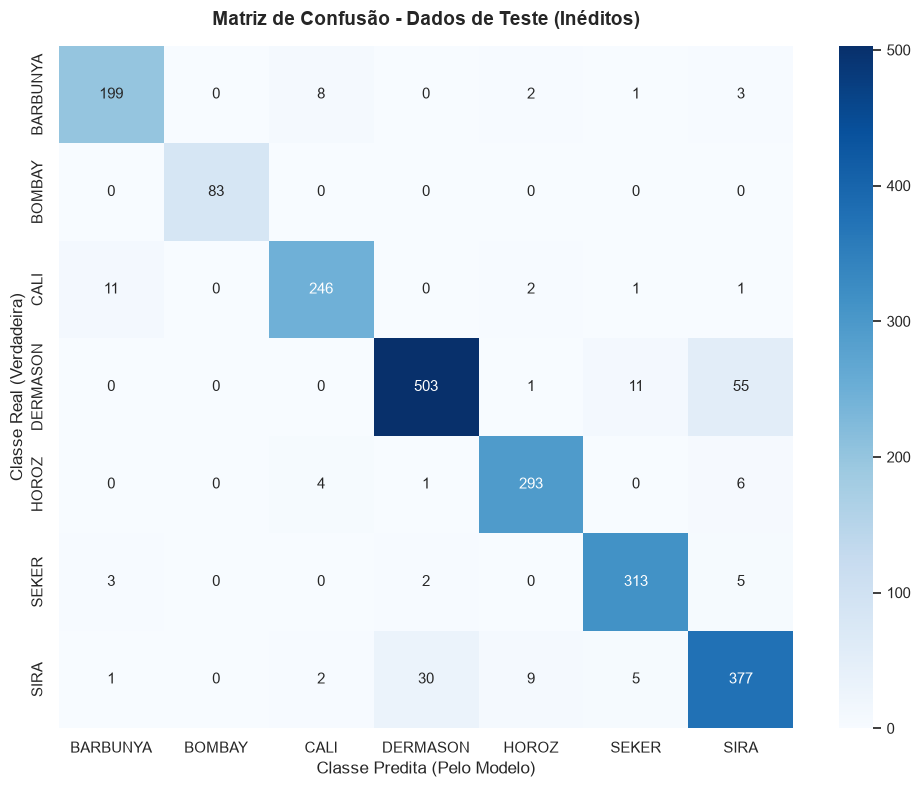

In [13]:

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs, 1)
        
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())

nomes_classes = encoder.classes_

print("--- Relatório de Classificação (Dados de Teste) ---")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, 
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão - Dados de Teste (Inéditos)', fontweight='bold', pad=15)
plt.ylabel('Classe Real (Verdadeira)')
plt.xlabel('Classe Predita (Pelo Modelo)')
plt.tight_layout()
plt.show()

F1 macro:            0.9383
Acurácia balanceada: 0.9402
Acurácia global:     0.9247


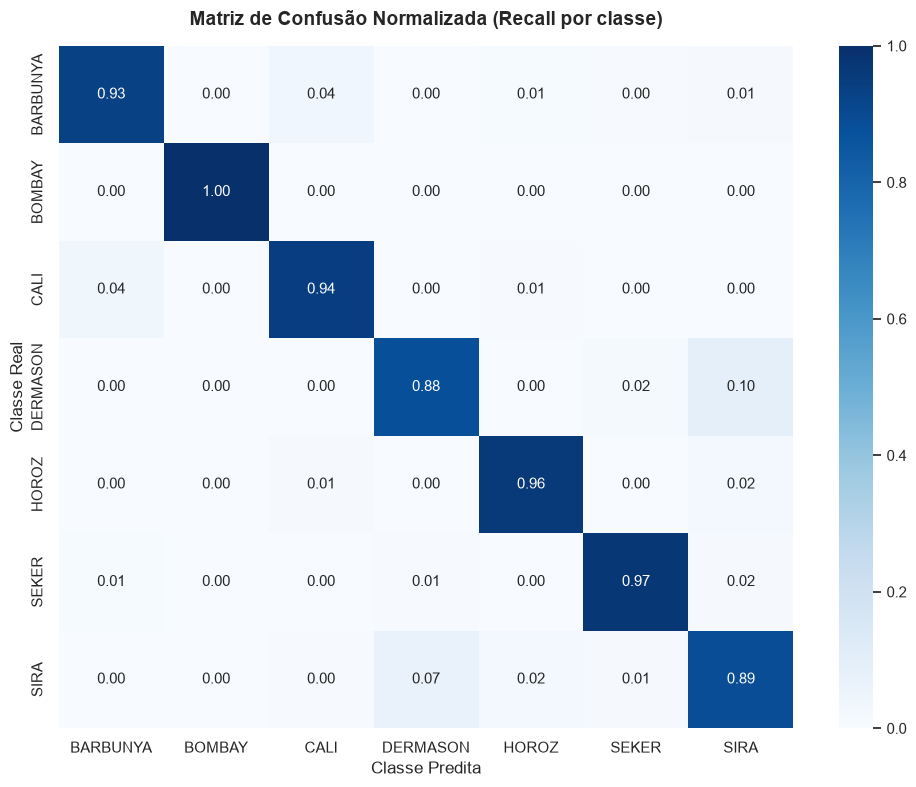

F1 por classe (pior -> melhor):
SIRA        0.866
DERMASON    0.910
BARBUNYA    0.932
CALI        0.944
SEKER       0.957
HOROZ       0.959
BOMBAY      1.000

Top 5 confusões (real -> predito):
  DERMASON  -> SIRA     : 55 amostras
  SIRA      -> DERMASON : 30 amostras
  CALI      -> BARBUNYA : 11 amostras
  DERMASON  -> SEKER    : 11 amostras
  SIRA      -> HOROZ    : 9 amostras


In [14]:
print(f'F1 macro:            {f1_score(y_true, y_pred, average="macro"):.4f}')
print(f'Acurácia balanceada: {balanced_accuracy_score(y_true, y_pred):.4f}')
print(f'Acurácia global:     {np.mean(np.array(y_true) == np.array(y_pred)):.4f}')

cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão Normalizada (Recall por classe)', fontweight='bold', pad=15)
plt.ylabel('Classe Real'); plt.xlabel('Classe Predita')
plt.tight_layout(); plt.show()

# Classes mais difíceis e pares mais confundidos
f1_cls = pd.Series(f1_score(y_true, y_pred, average=None), index=nomes_classes).sort_values()
print('F1 por classe (pior -> melhor):'); print(f1_cls.round(3).to_string())

erros = [(nomes_classes[i], nomes_classes[j], cm[i, j])
         for i in range(len(cm)) for j in range(len(cm)) if i != j]
print('\nTop 5 confusões (real -> predito):')
for r, p, n in sorted(erros, key=lambda t: -t[2])[:5]:
    print(f'  {r:9s} -> {p:9s}: {n} amostras')

### Curvas de treinamento

As curvas mostram se a loss de treino e a de validação convergem sem oscilações fortes, se a distância entre elas é pequena (ausência de sobreajuste relevante) e como o scheduler reduz o learning rate quando a validação estagna. A linha tracejada marca a época cujos pesos foram restaurados.

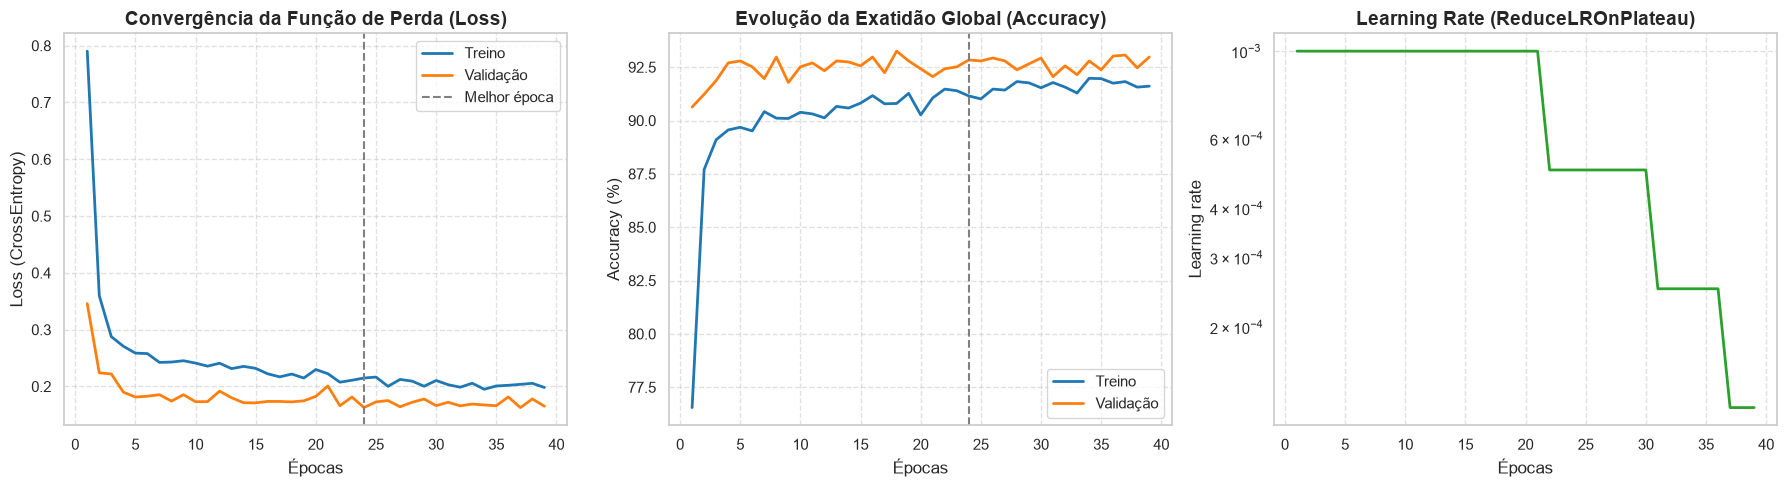

In [15]:
vetor_epocas = np.arange(1, len(train_losses) + 1)   # len(): o early stopping pode encerrar antes do limite

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(vetor_epocas, train_losses, label='Treino', color='#1f77b4', linewidth=2)
plt.plot(vetor_epocas, val_losses, label='Validação', color='#ff7f0e', linewidth=2)
plt.axvline(best_epoch, color='gray', linestyle='--', label='Melhor época')
plt.title('Convergência da Função de Perda (Loss)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.plot(vetor_epocas, train_accs, label='Treino', color='#1f77b4', linewidth=2)
plt.plot(vetor_epocas, val_accs, label='Validação', color='#ff7f0e', linewidth=2)
plt.axvline(best_epoch, color='gray', linestyle='--')
plt.title('Evolução da Exatidão Global (Accuracy)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
plt.plot(vetor_epocas, lrs, color='#2ca02c', linewidth=2)
plt.yscale('log')
plt.title('Learning Rate (ReduceLROnPlateau)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Learning rate')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Interpretação dos resultados

- **Métricas apropriadas.** Como as classes são desbalanceadas, a análise se apoia em F1 macro (0,938) e acurácia balanceada (0,940), além do desempenho por classe. Elas ficam próximas da acurácia global (0,925), o que indica que o modelo não sacrifica as classes minoritárias para acertar as majoritárias, efeito da ponderação da loss.
- **Classe mais fácil.** BOMBAY, a menor classe (83 amostras no teste), é separada perfeitamente (F1 = 1,00), pois seus grãos são muito maiores que os das demais classes (boxplot da área). Isso mostra que o desbalanceamento foi bem tratado.
- **Classes mais difíceis.** SIRA (F1 = 0,87) e DERMASON (F1 = 0,91) concentram os erros. As maiores confusões são DERMASON → SIRA (55 amostras) e SIRA → DERMASON (30), o que reflete sobreposição morfológica real entre essas classes, e não falha de treinamento.
- **Precisão vs. recall.** SIRA tem a menor precisão (0,84) porque "absorve" amostras de DERMASON; DERMASON, por sua vez, tem o menor recall (0,88) por perder amostras para SIRA. Como DERMASON é a maior classe (570 amostras), esses 55 erros pesam pouco no recall total da classe, mas pesam bastante na precisão de SIRA.
- **Generalização.** O F1 macro no teste (0,938) é praticamente igual ao da validação (≈ 0,941), sem sinal de sobreajuste ao conjunto de validação nem de vazamento entre as partições.
- **Efeito da regularização.** No experimento, o gap treino − validação é negativo em todas as configurações, ou seja, o modelo **não sobreajusta** mesmo sem regularização, e o F1 de validação praticamente não muda entre elas (0,9405 a 0,9416, diferença dentro da variação esperada de uma única semente). O gap é negativo em parte porque o F1 de treino é medido com o Dropout ativo. Portanto, os dados não mostram ganho mensurável do Dropout, do weight decay ou do scheduler neste dataset. Eles foram mantidos como medida preventiva de baixo custo (não prejudicam o desempenho), e o early stopping com checkpoint garante que o modelo final vem do ponto de melhor validação. A oscilação da loss também não foi menor na configuração completa, então não se pode afirmar ganho de estabilidade com base nesta comparação.
